Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [ ]:
from setup import *

# ER LH 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.11,31
,3000,0,0.11,95
,3000,0,0.11,95
,3000,0,0.12,31


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -529.41    38.35
p_loo       16.40        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



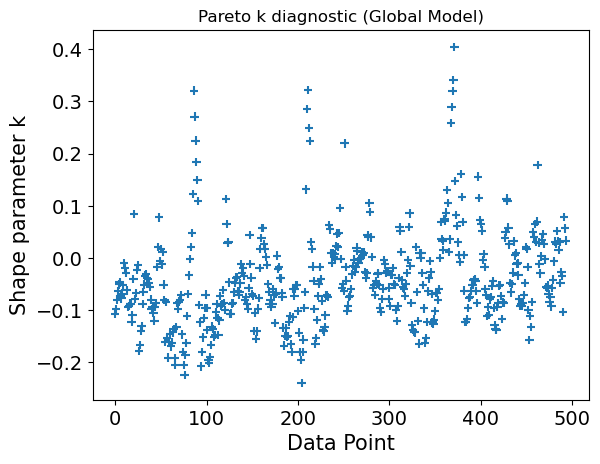

In [4]:
with pm.Model() as ER_LH_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.12, sigma=0.01, upper=0.0)
    deltaG4_0 = pm.TruncatedNormal('deltaG4_0', mu=0.0, sigma=0.05, upper=0.25) 
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.45, sigma=0.05) 
    beta_2 = pm.Beta('beta_2', alpha=50.0, beta=150.0)
    beta_3 = pm.Beta('beta_3', alpha=20.0, beta=20.0)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.74, sigma=0.005) 
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.76, sigma=0.005) 
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.65, sigma=0.05, lower=0.0) 

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0 
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    # Quadratic solver setup
    log_N_ER = log_k2_ER + term_CO + np.log(C_KOH_in)
    log_N_LH = log_k2_LH + term_CO + term_OH
    log_D1 = pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    log_D2 = log_k2_LH - log_K2_LH
    log_S_base = pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    a_quad = pt.exp(log_D1)
    b_quad = pt.exp(log_D1 + log_S_base) + pt.exp(log_D2) - pt.exp(log_N_ER)
    c_quad = -(pt.exp(log_N_ER + log_S_base) + pt.exp(log_N_LH))
    term_COOH = pt.log((-b_quad + pt.sqrt(b_quad**2 - 4*a_quad*c_quad)) / (2*a_quad))

    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_LH_2_3, loo_ER_LH_2_3 = fit_and_evaluate(ER_LH_2_3, target_accept=0.99)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_ER_0 -0.461  0.041  -0.535   -0.385      0.001    0.001    3568.0    2644.0   1.00
Gact2_ER_0    0.749  0.001   0.747    0.750      0.000    0.000    1484.0    1897.0   1.00
Gact2_LH_0    0.752  0.004   0.745    0.759      0.000    0.000    1768.0    2008.0   1.00
deltaG1_0    -0.110  0.002  -0.115   -0.105      0.000    0.000    1036.0    1549.0   1.00
deltaG4_0     0.008  0.007  -0.005    0.021      0.000    0.000    2806.0    2142.0   1.00
beta_2        0.214  0.009   0.197    0.230      0.000    0.000    1074.0    1520.0   1.01
beta_3        0.604  0.050   0.509    0.698      0.002    0.001     701.0    1107.0   1.01
Gact3_0       0.646  0.015   0.618    0.673      0.001    0.000     653.0    1051.0   1.01


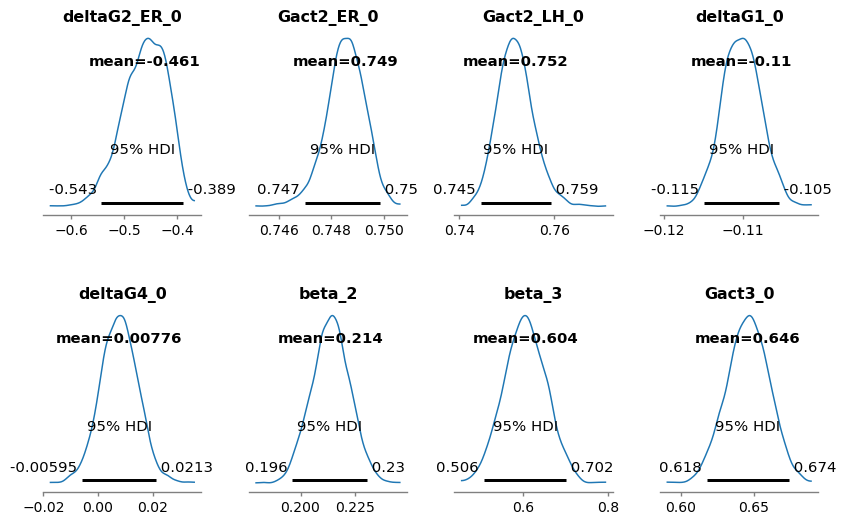

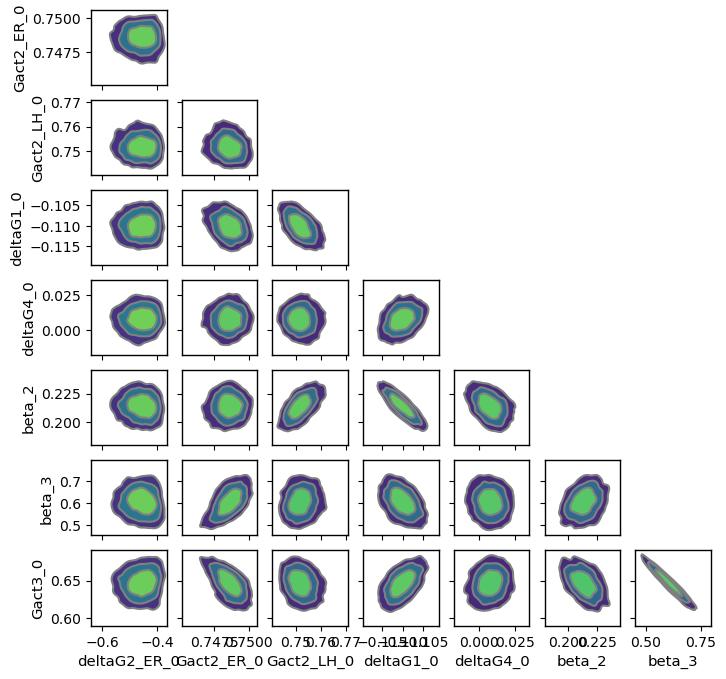

Sampling: [rate]


rate: 0.821


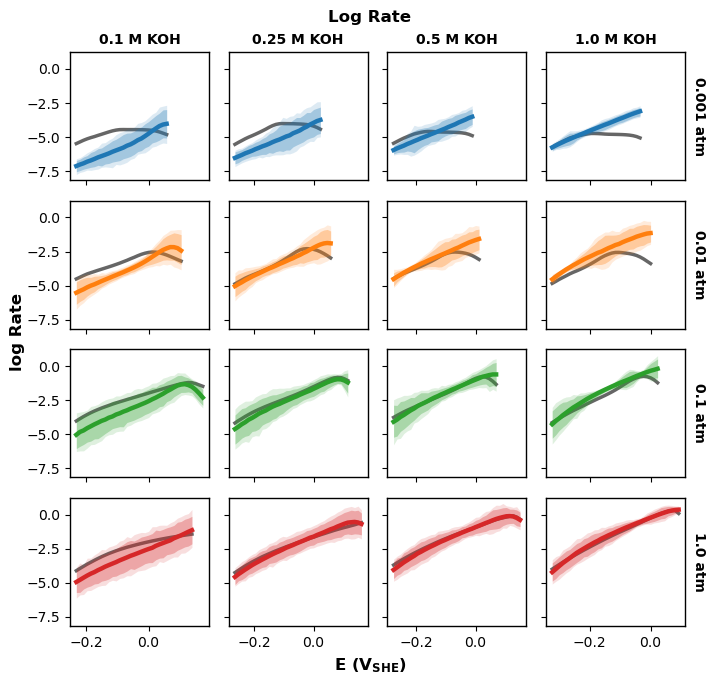

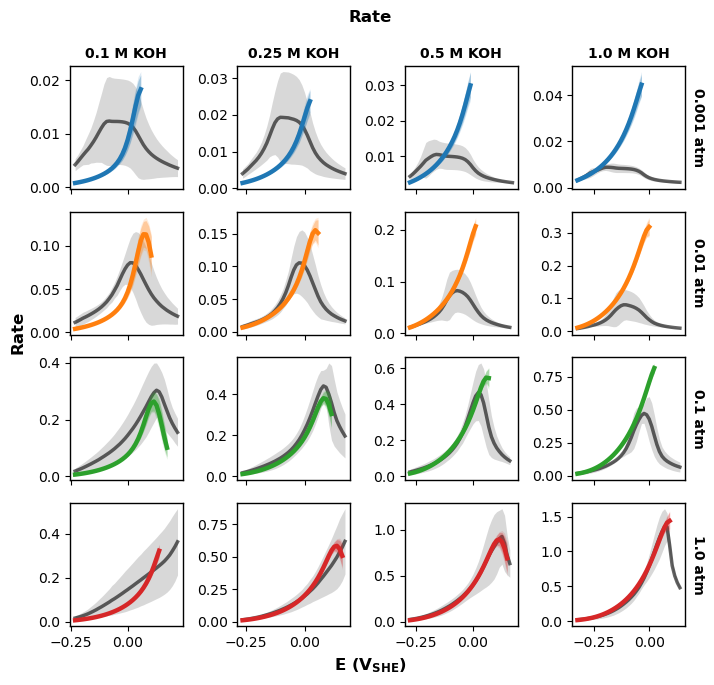

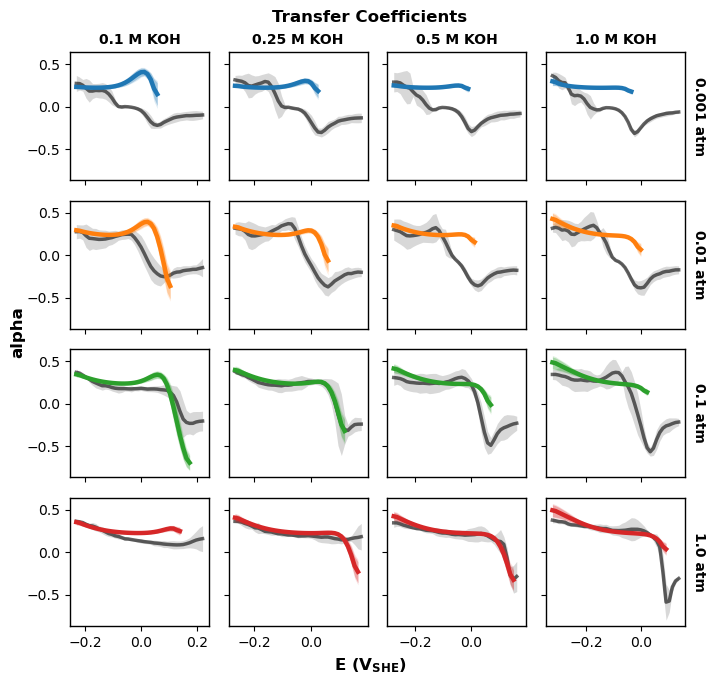

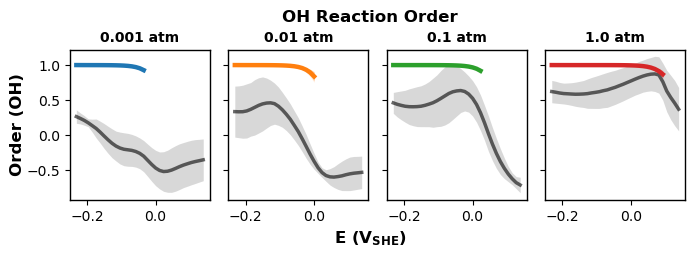

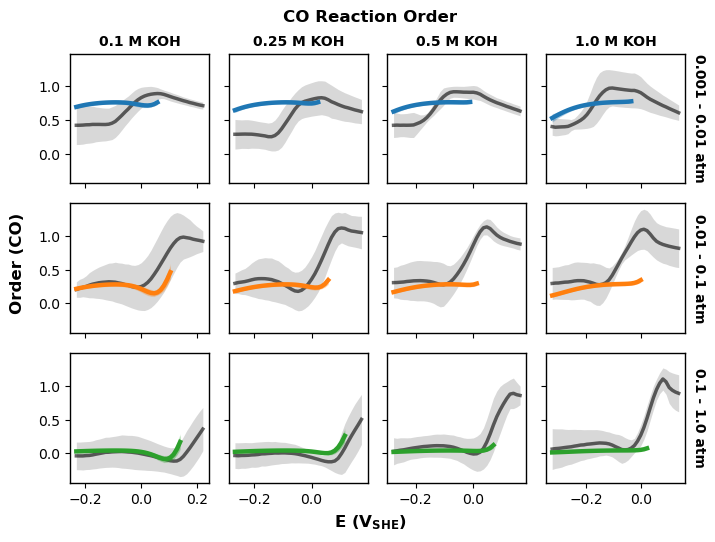

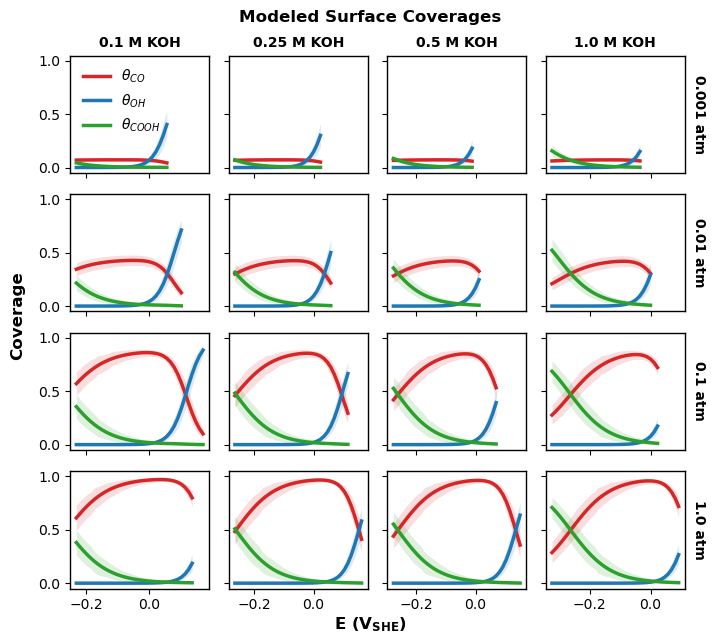

In [5]:
ppc_ER_LH_2_3 = plot_posteriors(trace_ER_LH_2_3, ER_LH_2_3, plot_target)
plot_model_fits(trace_ER_LH_2_3, ppc_ER_LH_2_3); plot_coverages(trace_ER_LH_2_3)

# ER 1 2 3 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.31,15
,3000,0,0.36,15
,3000,0,0.29,15
,3000,0,0.37,15


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -208.35    18.78
p_loo       11.10        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



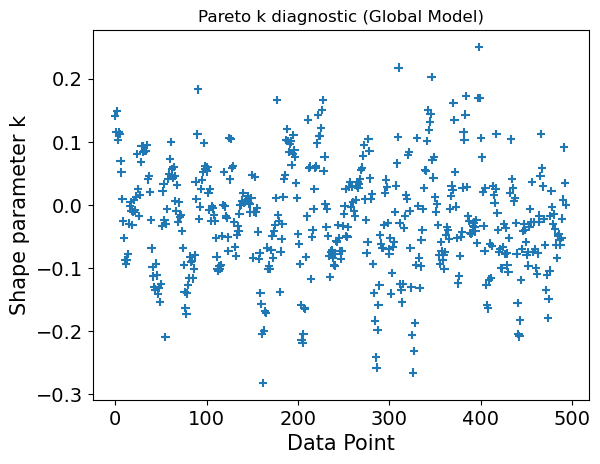

In [6]:
with pm.Model() as ER_1_2_3:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.113, sigma=0.05, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.09, sigma=0.05) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.457, sigma=0.05) # at 0V_SHE
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.222, sigma=0.02, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.619, sigma=0.05, lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.5, sigma=0.2, lower=0.0) 
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.02) # at 0V_SHE
    Gact3_0 = pm.Normal('Gact3_0', mu=0.64, sigma=0.02) # at 0V_SHE

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2*E_in 
    Gact3 = Gact3_0 - beta_3*E_in  
    
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    log_denom_COOH = pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    log_ratio_COOH_CO = log_k2_ER + np.log(C_KOH_in) - log_denom_COOH
    log_k_eff = log_k3 + np.log(C_KOH_in) + log_ratio_COOH_CO
    log_denom_CO = pt.logaddexp(log_k1 - log_K1, log_k_eff)
    
    term_CO = log_k1 + np.log(P_CO_in) - log_denom_CO
    term_COOH = term_CO + log_ratio_COOH_CO
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = -pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)

    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression 
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)  

trace_ER_1_2_3, loo_ER_1_2_3 = fit_and_evaluate(ER_1_2_3)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0     0.097  0.014   0.078    0.119      0.000    0.002    2218.0    1405.0   1.00
deltaG2_ER_0 -0.465  0.044  -0.545   -0.384      0.001    0.001    5042.0    2848.0   1.00
Gact2_0       0.744  0.001   0.743    0.746      0.000    0.000    2524.0    2585.0   1.00
Gact3_0       0.647  0.010   0.629    0.665      0.000    0.000     738.0    1107.0   1.01
deltaG1_0    -0.248  0.021  -0.289   -0.211      0.000    0.000    4752.0    2622.0   1.00
beta_2        0.219  0.010   0.199    0.238      0.000    0.000    1620.0    2130.0   1.00
beta_3        0.662  0.032   0.604    0.724      0.001    0.001     746.0    1020.0   1.01
Gact1_0       0.688  0.001   0.686    0.689      0.000    0.000    4864.0    2346.0   1.00


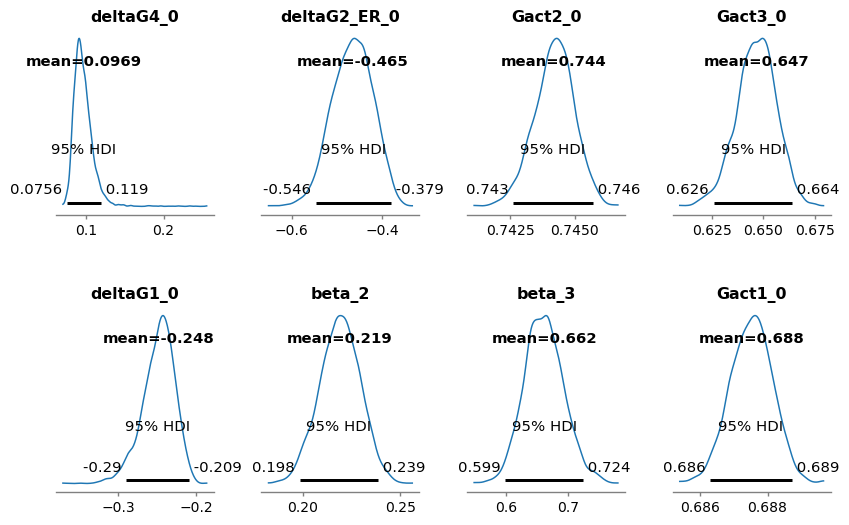

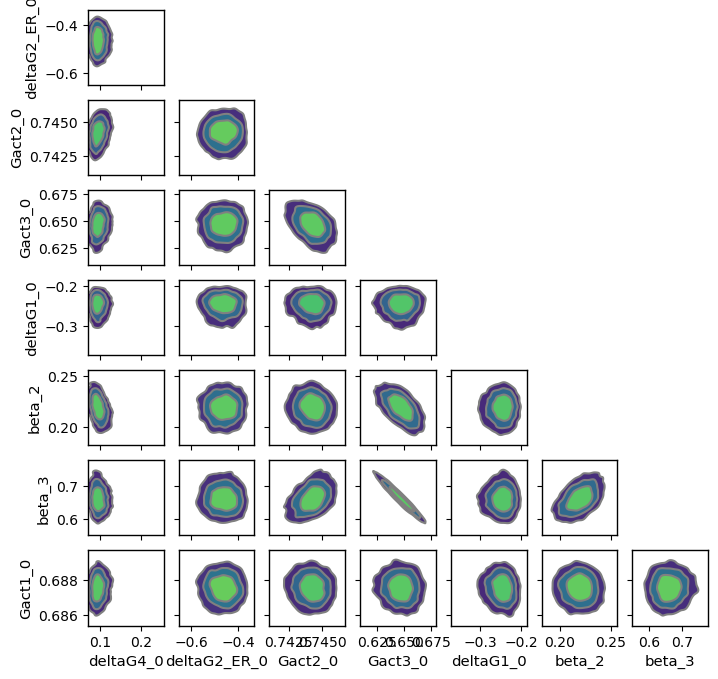

Sampling: [rate]


rate: 0.874


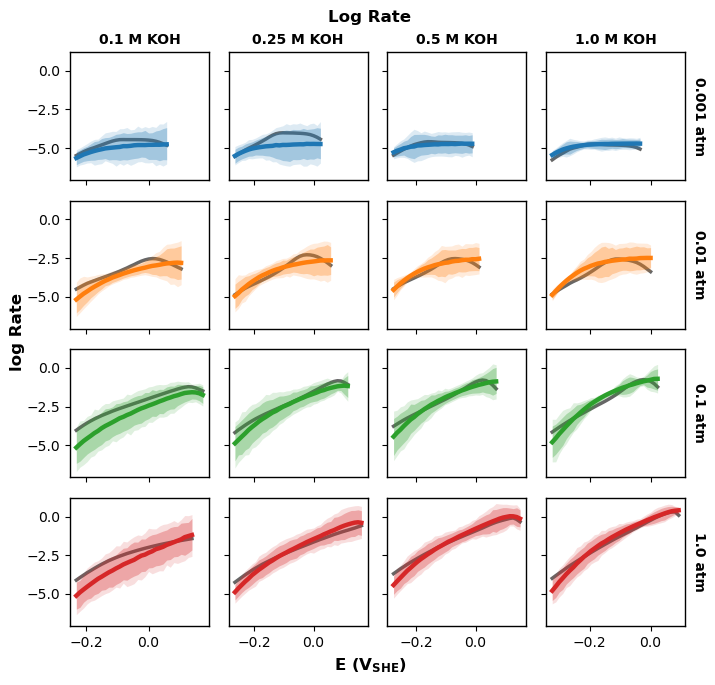

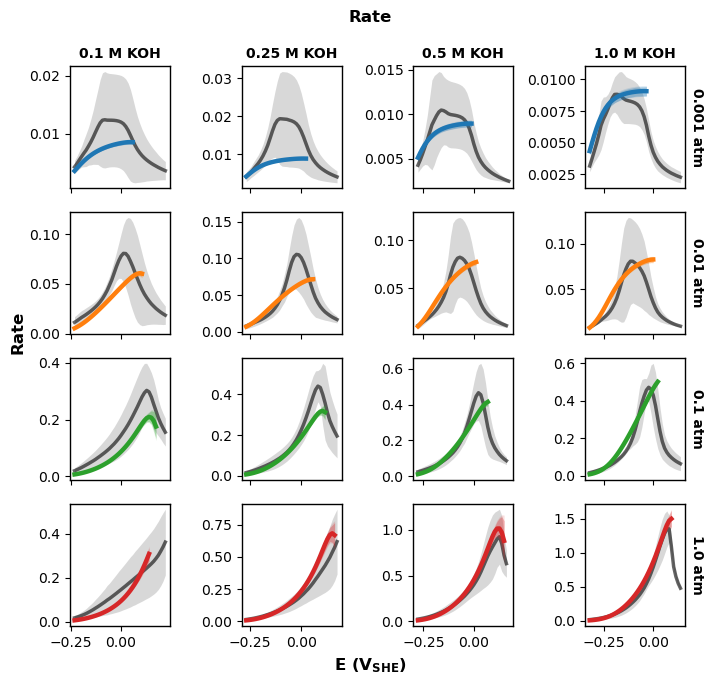

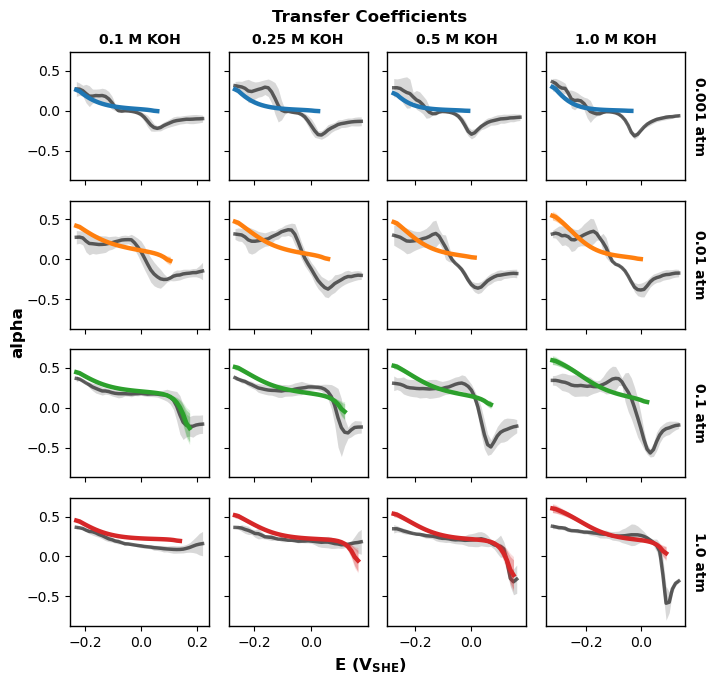

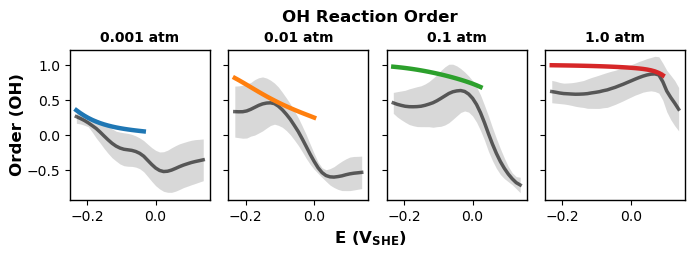

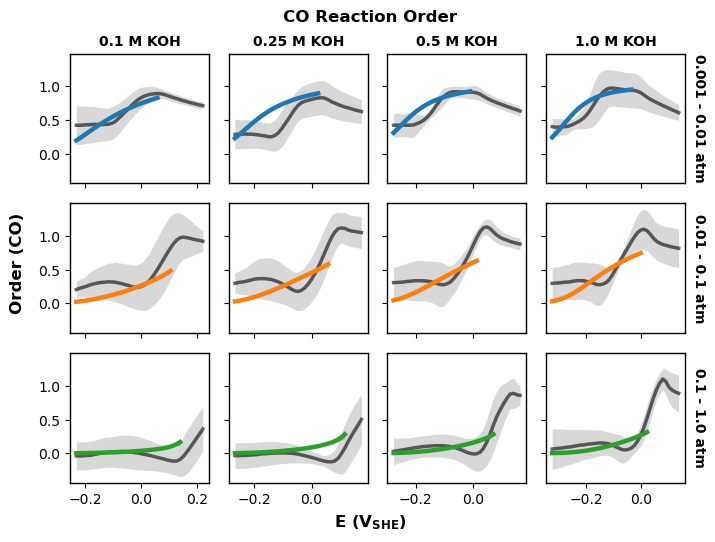

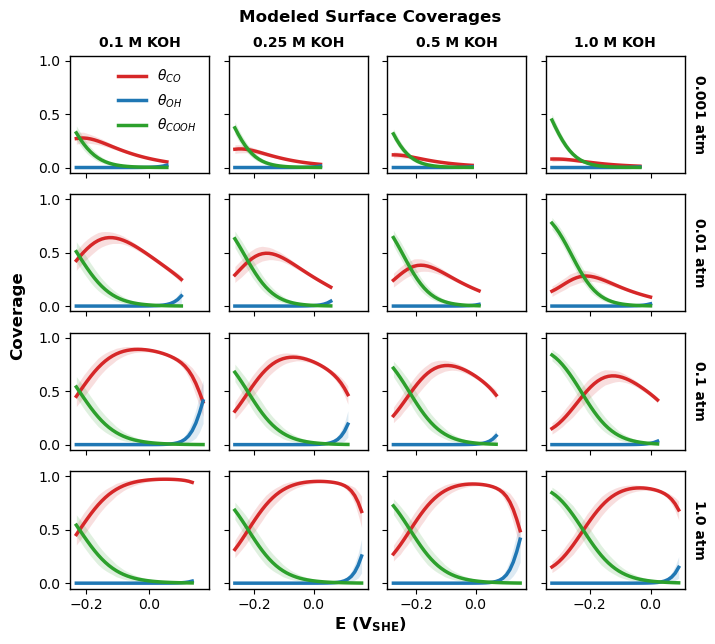

In [7]:
ppc_ER_1_2_3 = plot_posteriors(trace_ER_1_2_3, ER_1_2_3, plot_target)
plot_model_fits(trace_ER_1_2_3, ppc_ER_1_2_3); plot_coverages(trace_ER_1_2_3)

# ER LH 2 3 4

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,31
,3000,0,0.12,63
,3000,0,0.11,63
,3000,0,0.12,63


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -417.41    34.87
p_loo       17.29        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      493   99.8%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    0    0.0%



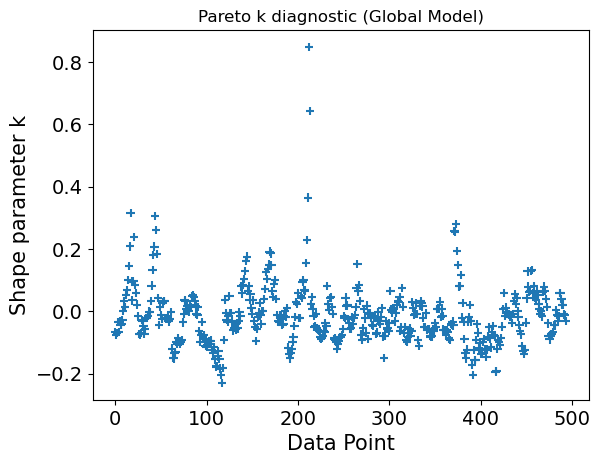

In [14]:
with pm.Model() as ER_LH_2_3_4:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) (SSA)
    4. OH- + * <-> OH* + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.11, sigma=0.02, lower=-0.25, upper=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.008, sigma=0.007) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.461, sigma=0.041) # at 0V_SHE
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.213, sigma=0.008, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.599, sigma=0.052, lower=0.0, upper=1.0)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.752, sigma=0.004) 
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.748, sigma=0.001) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.648, sigma=0.015, lower=0.4, upper=1.5) # at 0V_SHE
    Gact4_0 = pm.TruncatedNormal('Gact4_0', mu=0.5, sigma=0.2, lower=0.5) # at 0V_SHE

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact2_LH = Gact2_LH_0 
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    Gact4 = Gact4_0 - beta_4*E_in

    log_K1 = -deltaG1 / (kb_eV*T)
    log_K2_LH = -deltaG2_LH / (kb_eV*T)
    log_K2_ER = -deltaG2_ER / (kb_eV*T)
    log_K4 = -deltaG4 / (kb_eV*T)

    log_prefactor = np.log(kb_J*T/h)
    log_k2_ER = log_prefactor - Gact2_ER / (kb_eV*T)
    log_k2_LH = log_prefactor - Gact2_LH / (kb_eV*T)
    log_k3 = log_prefactor - Gact3 / (kb_eV*T)
    log_k4 = log_prefactor - Gact4 / (kb_eV*T)

    term_CO = pt.exp(log_K1) * P_CO_in
    R2_ER_f = pt.exp(log_k2_ER) * C_KOH_in
    R2_ER_b = pt.exp(log_k2_ER - log_K2_ER)
    R2_LH_f = pt.exp(log_k2_LH)
    R2_LH_b = pt.exp(log_k2_LH - log_K2_LH)
    R3 = pt.exp(log_k3) * C_KOH_in
    R4_f = pt.exp(log_k4) * C_KOH_in
    R4_b = pt.exp(log_k4 - log_K4)

    # Quadratic solver setup
    c_OH_CO = (R4_f / term_CO + R2_ER_f ) / R4_b 
    c_OH_COOH = -(R2_ER_b + R3) / R4_b
    K_CO = 1/term_CO + 1.0 + c_OH_CO
    K_COOH = 1.0 + c_OH_COOH

    slope_COOH = -K_CO
    int_OH = c_OH_COOH
    slope_OH = c_OH_CO * K_COOH - c_OH_COOH * K_CO
    slope_star = 1/term_CO * K_COOH 

    a_quad = -R2_LH_f * K_COOH * slope_OH + R2_LH_b * slope_COOH * slope_star
    b_quad = (
        -R2_LH_f * K_COOH * int_OH
        + R2_LH_b * (slope_star) - R2_ER_f * (K_COOH ** 2)
        + (R2_ER_b + R3) * K_COOH * slope_COOH)
    c_quad = (R2_ER_b + R3) * K_COOH

    discriminant = b_quad**2.0 - 4.0 * a_quad * c_quad; safe_discriminant = pt.maximum(discriminant, 1e-12)
    b_sign = pt.switch(pt.lt(b_quad, 0.0), -1.0, 1.0)
    q = -0.5 * (b_quad + b_sign * pt.sqrt(safe_discriminant))
    safe_a = pt.switch(pt.eq(a_quad, 0.0), 1e-12, a_quad); safe_q = pt.switch(pt.eq(q, 0.0), 1e-12, q)
    root_1 = q / safe_a; root_2 = c_quad / safe_q
    valid_1 = (root_1 >= -1e-6) & (root_1 <= 1.0 + 1e-6)
    theta_CO_raw = pt.where(valid_1, root_1, root_2)
    safe_K_COOH = pt.switch(pt.eq(K_COOH, 0.0), 1e-12, K_COOH)

    theta_CO   = pm.Deterministic('theta_CO', theta_CO_raw)
    theta_COOH = pm.Deterministic('theta_COOH', (1.0 + slope_COOH * theta_CO) / safe_K_COOH)
    theta_OH   = pm.Deterministic('theta_OH', (int_OH + slope_OH * theta_CO) / safe_K_COOH)

    # Rate expression
    log_rate_model = pt.log(R3 * theta_COOH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2_3_4, loo_ER_LH_2_3_4 = fit_and_evaluate(ER_LH_2_3_4, target_accept=0.99)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0    -0.073  0.006  -0.084   -0.062      0.000    0.000    2787.0    2171.0    1.0
deltaG2_ER_0 -0.453  0.037  -0.520   -0.393      0.001    0.001    2793.0    2557.0    1.0
Gact2_LH_0    0.749  0.003   0.744    0.754      0.000    0.000    1242.0    1958.0    1.0
Gact2_ER_0    0.753  0.001   0.751    0.755      0.000    0.000    1512.0    1848.0    1.0
deltaG1_0    -0.094  0.002  -0.098   -0.090      0.000    0.000    1441.0    2055.0    1.0
beta_2        0.186  0.007   0.174    0.199      0.000    0.000    2023.0    2481.0    1.0
beta_3        0.391  0.016   0.360    0.419      0.000    0.000    1337.0    1589.0    1.0
beta_4        0.117  0.057   0.025    0.221      0.001    0.001    2869.0    2644.0    1.0
Gact3_0       0.725  0.003   0.719    0.732      0.000    0.000    1121.0    1377.0    1.0
Gact4_0       0.714  0.005   0.704    0.724      0.000    0.000    2718.0    2657.0    1.0

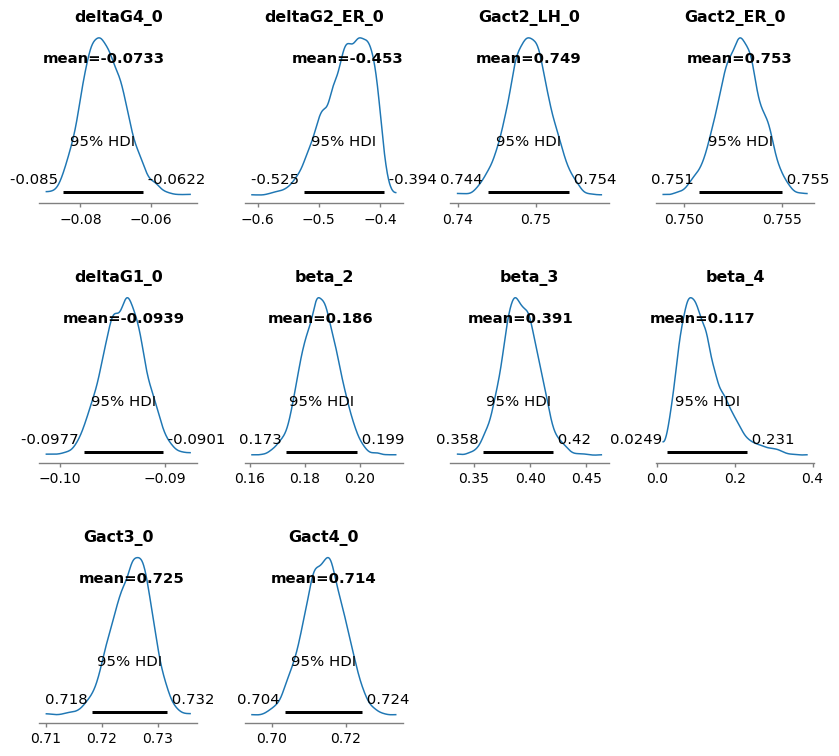

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


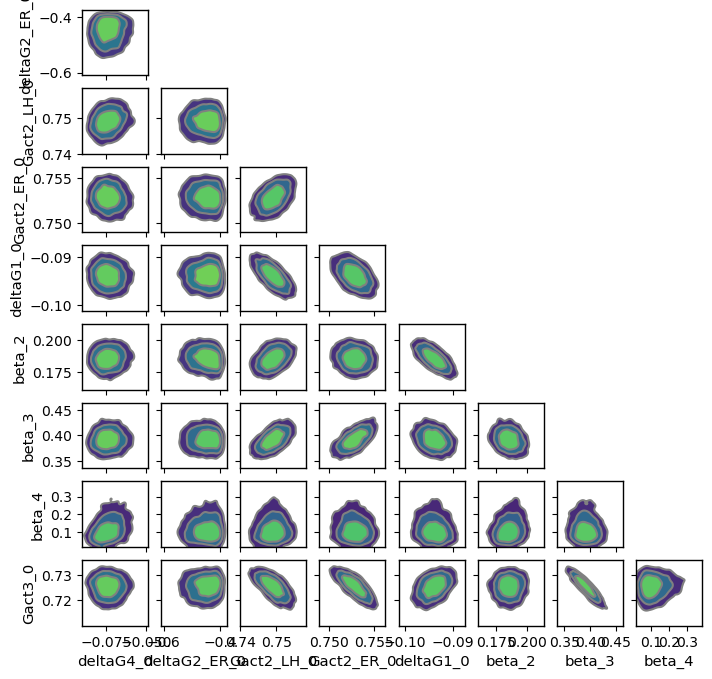

Sampling: [rate]


rate: 0.849


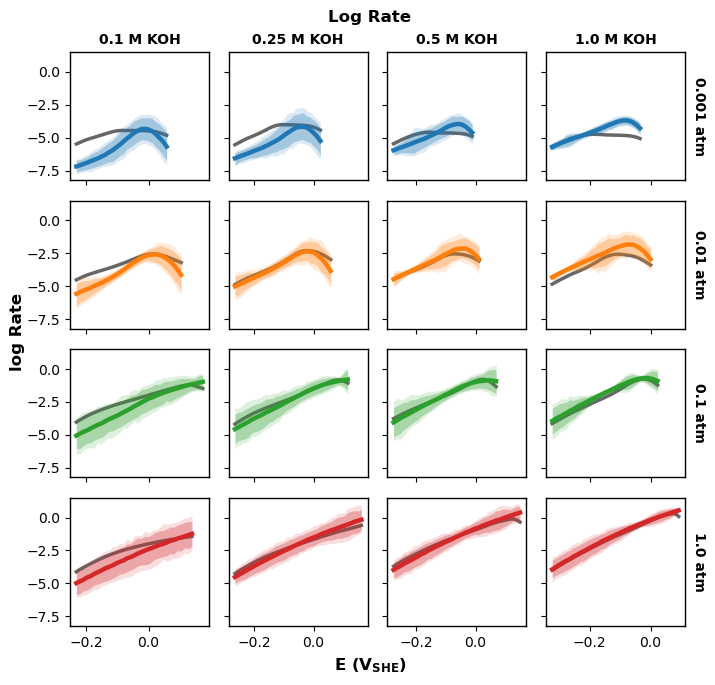

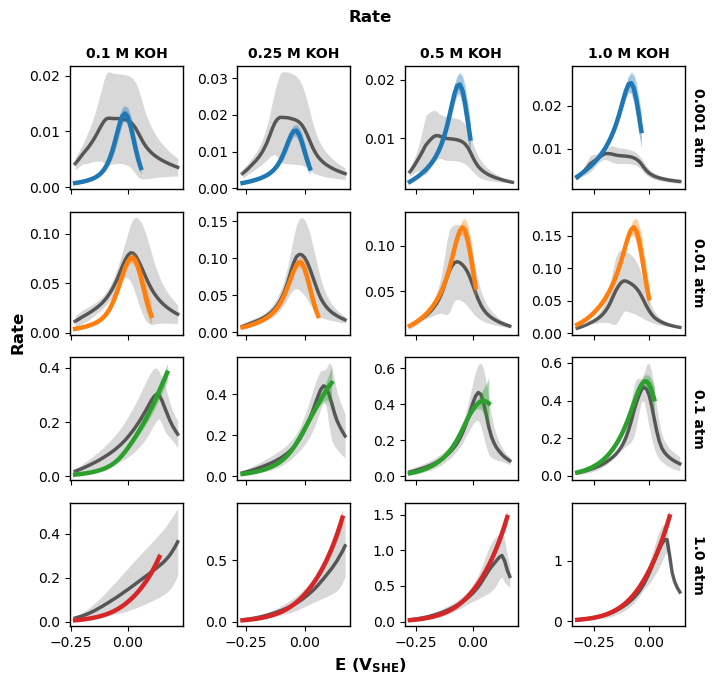

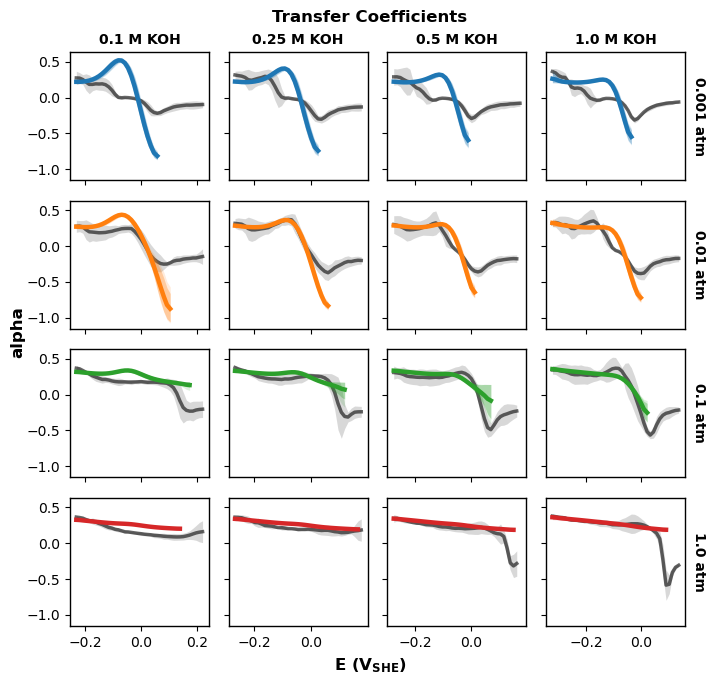

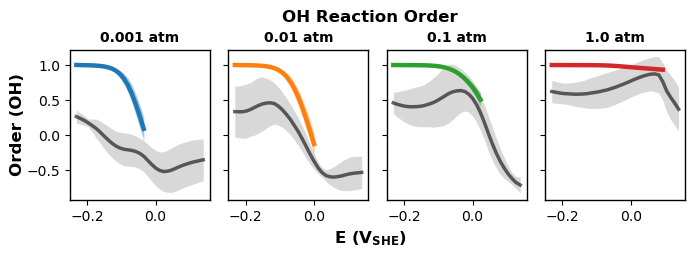

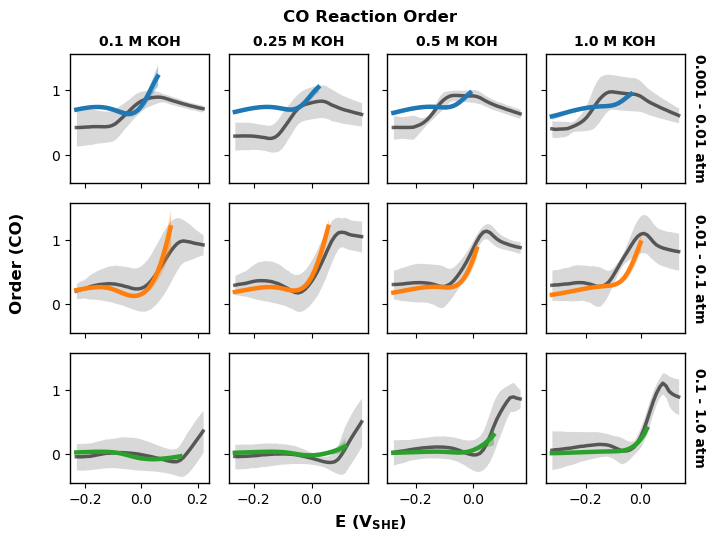

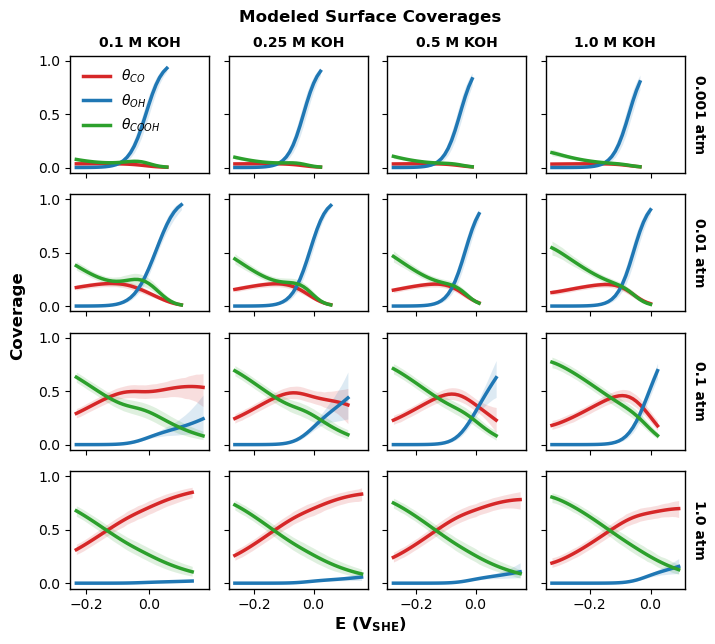

In [15]:
ppc_ER_LH_2_3_4 = plot_posteriors(trace_ER_LH_2_3_4, ER_LH_2_3_4, plot_target)
plot_model_fits(trace_ER_LH_2_3_4, ppc_ER_LH_2_3_4); plot_coverages(trace_ER_LH_2_3_4)

# Full

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,127
,3000,0,0.12,31
,3000,0,0.10,31
,3000,0,0.12,31


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -152.37    19.60
p_loo       10.46        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



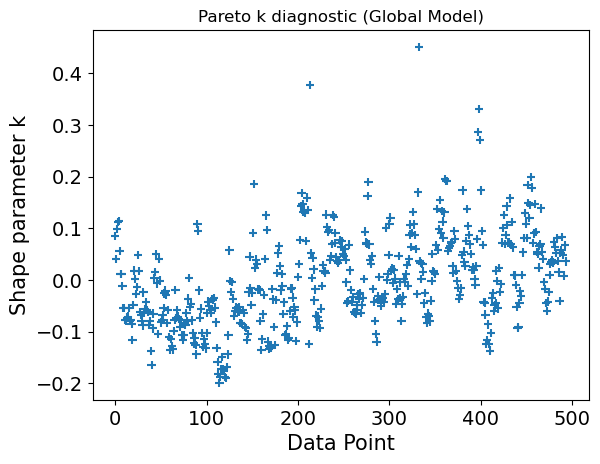

In [10]:
with pm.Model() as full:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) (SSA)
    4. OH- + * <-> OH* + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.25, sigma=0.05, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.09, sigma=0.05) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.46, sigma=0.05) # at 0V_SHE
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.22, sigma=0.02, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.66, sigma=0.05, lower=0.0, upper=1.0)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=25)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.688, sigma=0.05)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.752, sigma=0.05) 
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.748, sigma=0.02) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.648, sigma=0.05, lower=0.0) # at 0V_SHE
    Gact4_0 = pm.TruncatedNormal('Gact4_0', mu=0.702, sigma=0.05, lower=0.0) # at 0V_SHE

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact1 = Gact1_0
    Gact2_LH = Gact2_LH_0 
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    Gact4 = Gact4_0 - beta_4*E_in

    log_K1 = -deltaG1 / (kb_eV*T)
    log_K2_LH = -deltaG2_LH / (kb_eV*T)
    log_K2_ER = -deltaG2_ER / (kb_eV*T)
    log_K4 = -deltaG4 / (kb_eV*T)

    log_prefactor = np.log(kb_J*T/h)
    log_k1 = log_prefactor - Gact1 / (kb_eV*T)
    log_k2_ER = log_prefactor - Gact2_ER / (kb_eV*T)
    log_k2_LH = log_prefactor - Gact2_LH / (kb_eV*T)
    log_k3 = log_prefactor - Gact3 / (kb_eV*T)
    log_k4 = log_prefactor - Gact4 / (kb_eV*T)

    R1_f = pt.exp(log_k1) * P_CO_in
    R1_b = pt.exp(log_k1 - log_K1)
    R2_ER_f = pt.exp(log_k2_ER) * C_KOH_in
    R2_ER_b = pt.exp(log_k2_ER - log_K2_ER)
    R2_LH_f = pt.exp(log_k2_LH)
    R2_LH_b = pt.exp(log_k2_LH - log_K2_LH)
    R3 = pt.exp(log_k3) * C_KOH_in
    R4_f = pt.exp(log_k4) * C_KOH_in
    R4_b = pt.exp(log_k4 - log_K4)

    # Quadratic solver setup
    c_star_CO = R1_b / R1_f
    c_star_COOH = R3 / R1_f 
    c_OH_CO = (R4_f * c_star_CO + R2_ER_f ) / R4_b 
    c_OH_COOH = (R4_f * c_star_COOH - R2_ER_b - R3) / R4_b
    K_CO = c_star_CO + 1.0 + c_OH_CO
    K_COOH = c_star_COOH + 1.0 + c_OH_COOH

    slope_COOH = -K_CO
    int_OH = c_OH_COOH
    slope_OH = c_OH_CO * K_COOH - c_OH_COOH * K_CO
    int_star = c_star_COOH
    slope_star = c_star_CO * K_COOH + c_star_COOH * slope_COOH

    a_quad = -R2_LH_f * K_COOH * slope_OH + R2_LH_b * slope_COOH * slope_star
    b_quad = (
        -R2_LH_f * K_COOH * int_OH
        + R2_LH_b * (slope_star + int_star * slope_COOH)
        - R2_ER_f * (K_COOH ** 2)
        + (R2_ER_b + R3) * K_COOH * slope_COOH
    )
    c_quad = (R2_ER_b + R3) * K_COOH + R2_LH_b * int_star

    discriminant = b_quad**2.0 - 4.0 * a_quad * c_quad; safe_discriminant = pt.maximum(discriminant, 1e-12)
    b_sign = pt.switch(pt.lt(b_quad, 0.0), -1.0, 1.0)
    q = -0.5 * (b_quad + b_sign * pt.sqrt(safe_discriminant))
    safe_a = pt.switch(pt.eq(a_quad, 0.0), 1e-12, a_quad)
    safe_q = pt.switch(pt.eq(q, 0.0), 1e-12, q)
    root_1 = q / safe_a; root_2 = c_quad / safe_q
    valid_1 = (root_1 >= -1e-6) & (root_1 <= 1.0 + 1e-6)
    theta_CO_raw = pt.where(valid_1, root_1, root_2)
    safe_K_COOH = pt.switch(pt.eq(K_COOH, 0.0), 1e-12, K_COOH)

    theta_CO   = pm.Deterministic('theta_CO', theta_CO_raw)
    theta_COOH = pm.Deterministic('theta_COOH', (1.0 + slope_COOH * theta_CO) / safe_K_COOH)
    theta_OH   = pm.Deterministic('theta_OH', (int_OH + slope_OH * theta_CO) / safe_K_COOH)

    # Rate expression
    log_rate_model = pt.log(R3 * theta_COOH)
    log_rate = observables(log_rate_model)

trace_full, loo_full = fit_and_evaluate(full, target_accept=0.99)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0     0.003  0.005  -0.006    0.012      0.000    0.000    2788.0    2608.0    1.0
deltaG2_ER_0 -0.469  0.045  -0.554   -0.390      0.001    0.001    5109.0    2587.0    1.0
Gact1_0       0.688  0.001   0.687    0.689      0.000    0.000    2744.0    2874.0    1.0
Gact2_LH_0    0.696  0.005   0.686    0.705      0.000    0.000    2034.0    2442.0    1.0
Gact2_ER_0    0.750  0.001   0.748    0.751      0.000    0.000    2064.0    2694.0    1.0
deltaG1_0    -0.285  0.035  -0.350   -0.223      0.001    0.001    5120.0    3302.0    1.0
beta_2        0.189  0.010   0.171    0.207      0.000    0.000    1440.0    1906.0    1.0
beta_3        0.691  0.035   0.625    0.757      0.001    0.001     798.0    1080.0    1.0
beta_4        0.098  0.033   0.040    0.162      0.001    0.000    2553.0    2251.0    1.0
Gact3_0       0.639  0.010   0.619    0.658      0.000    0.000     773.0    1071.0    1.0

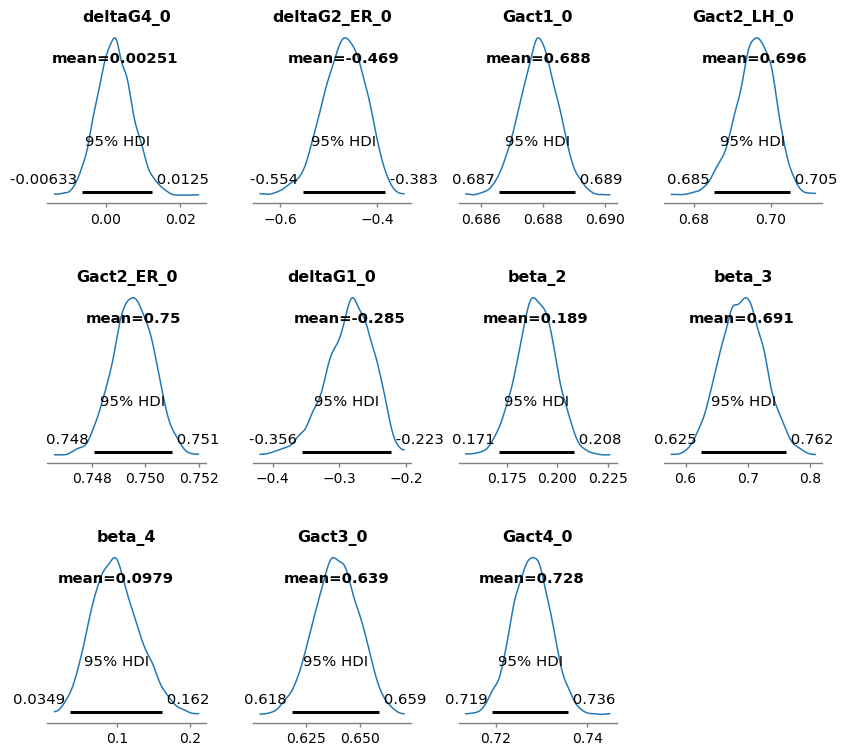

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


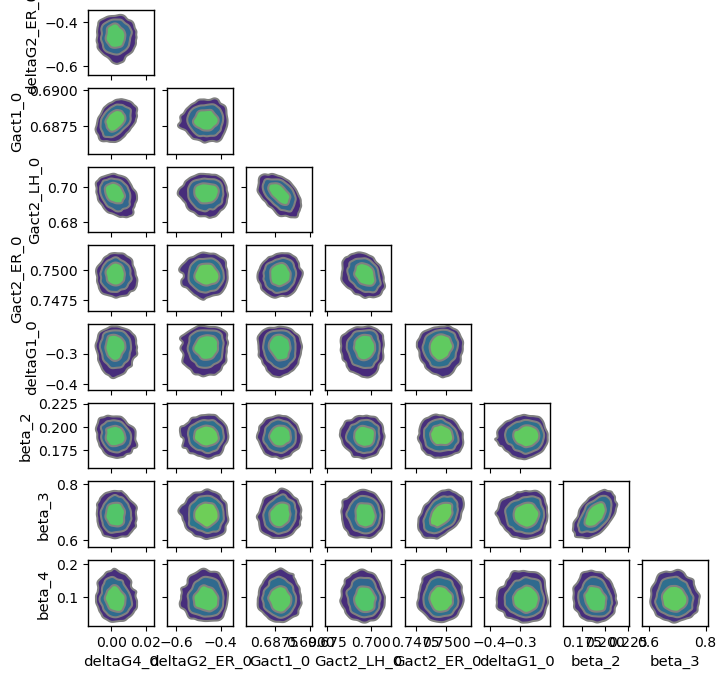

Sampling: [rate]


rate: 0.876


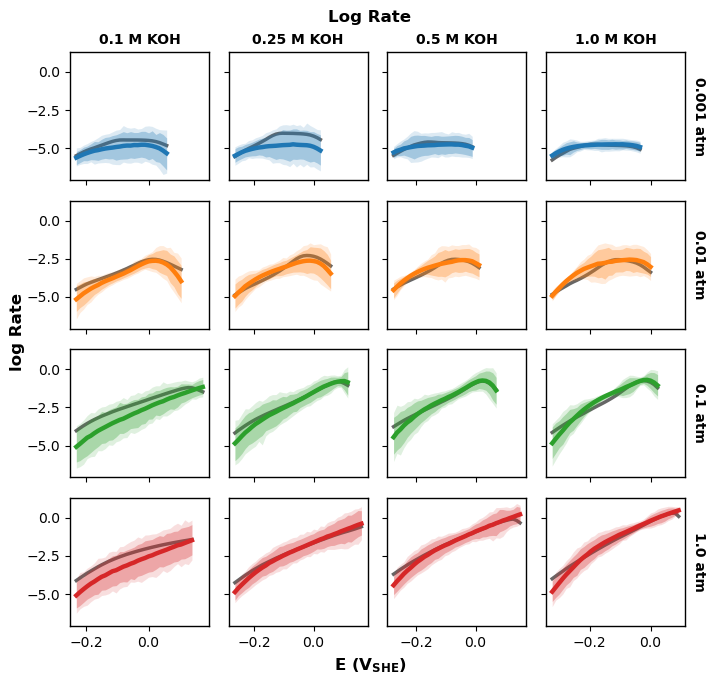

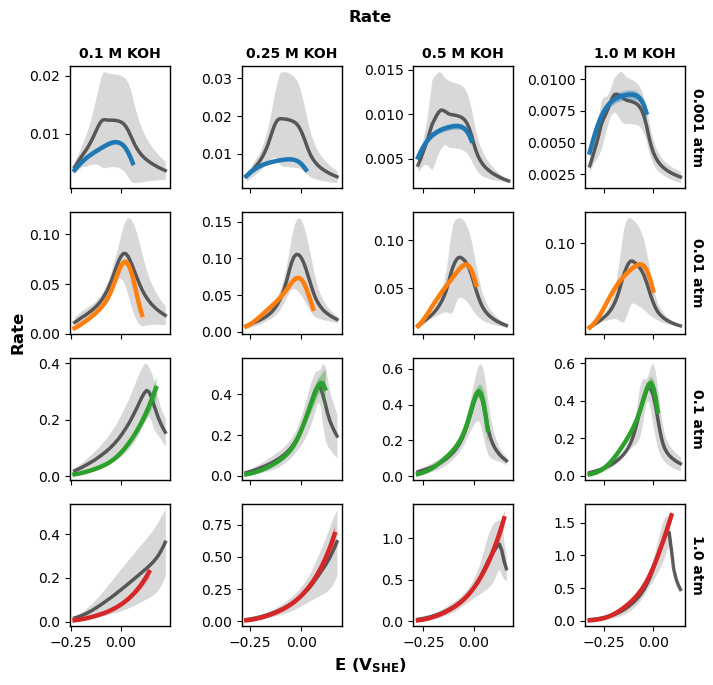

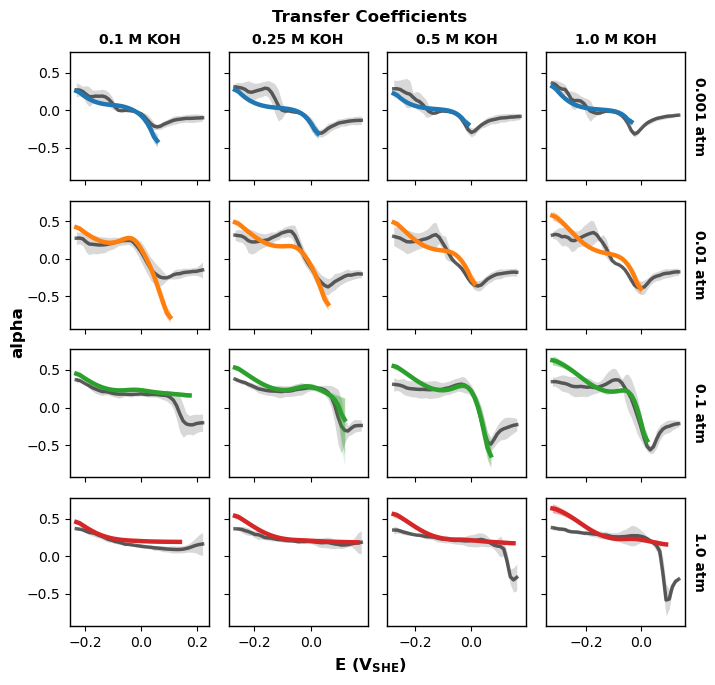

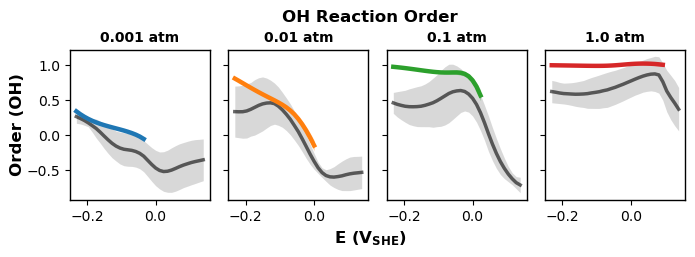

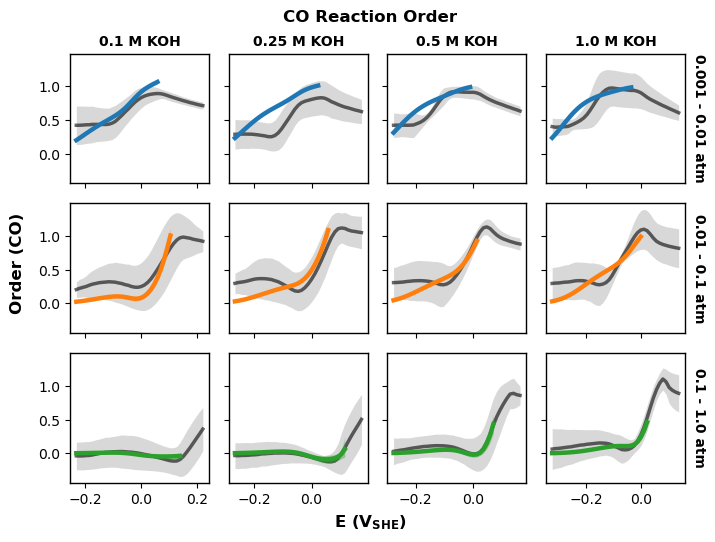

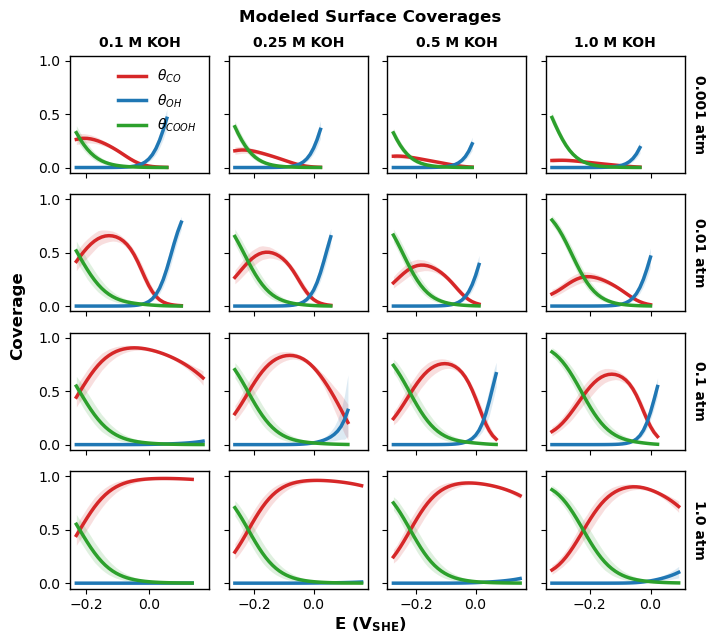

In [11]:
ppc_full = plot_posteriors(trace_full, full, plot_target)
plot_model_fits(trace_full, ppc_full); plot_coverages(trace_full)

# Comparison

             rank    elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
full            0 -152.369202  10.459705    0.000000  8.949981e-01  19.595925   0.000000    False   log
ER_1_2_3        1 -208.346621  11.100978   55.977420  5.131268e-13  18.775205   9.685655    False   log
ER_LH_2_3_4     2 -417.411748  17.289601  265.042546  1.050019e-01  34.866476  34.742580     True   log
ER_LH_2_3       3 -529.409710  16.401970  377.040508  2.824752e-11  38.351401  38.804412    False   log


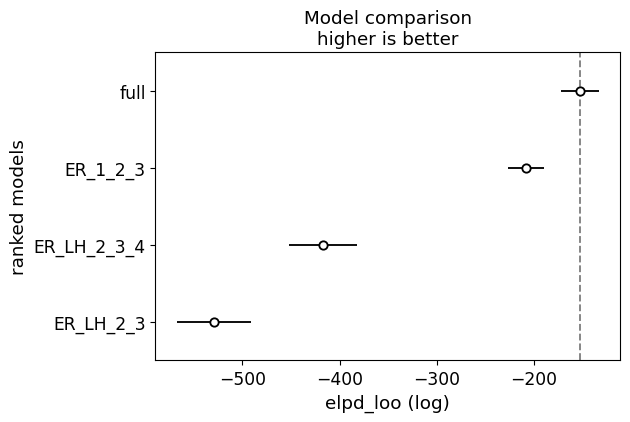

In [16]:
comparison_dict = {
    "ER_LH_2_3": loo_ER_LH_2_3,
    "ER_1_2_3": loo_ER_1_2_3,
    "ER_LH_2_3_4": loo_ER_LH_2_3_4,
    "full": loo_full,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

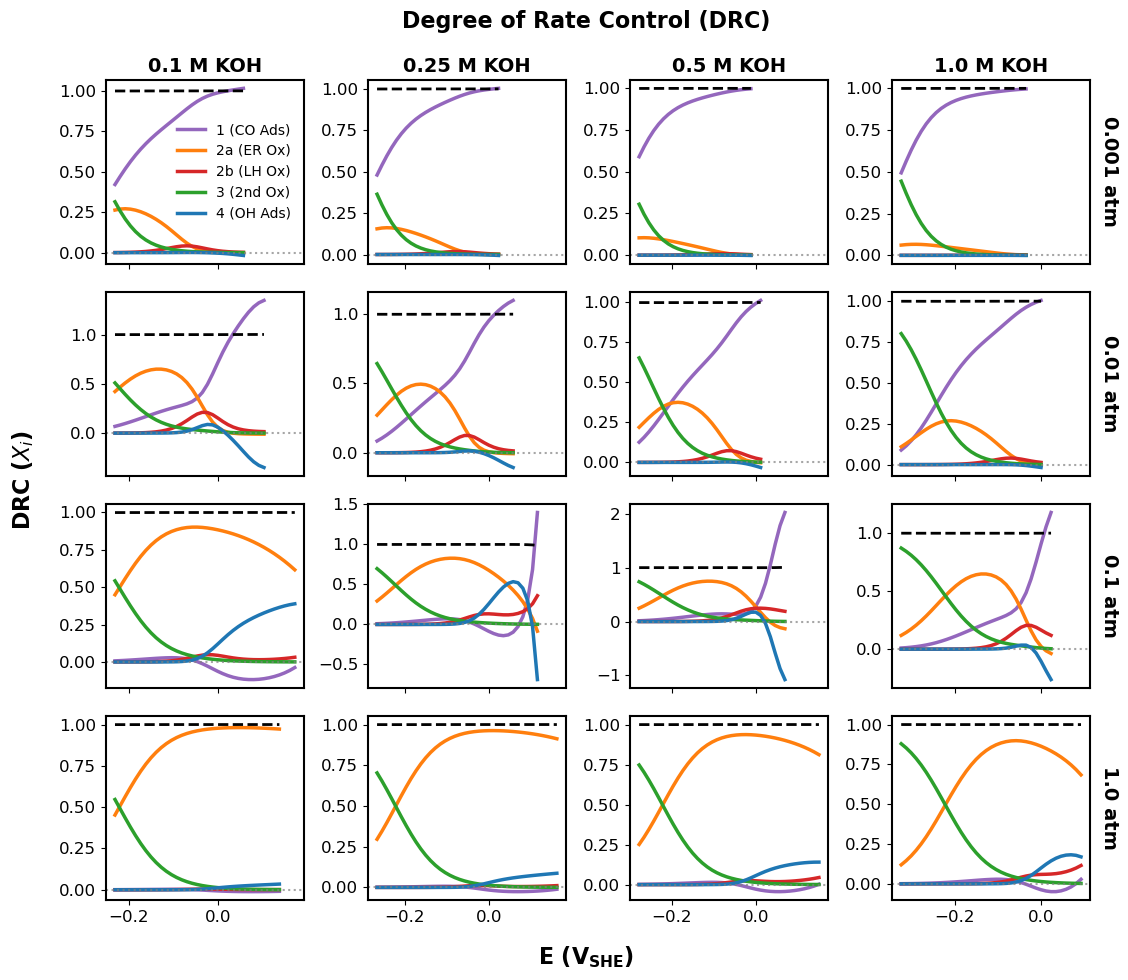

In [13]:
from scipy.optimize import fsolve

kB_eV = 8.617333262145e-5  # eV/K
h_eV_s = 4.135667696e-15   # eV*s
T = 298.15
kT = kB_eV * T
kT_h = kT / h_eV_s

# Posterior means from the `full` model
params = {
    'deltaG4_0': 0.002,
    'deltaG2_ER_0': -0.469,
    'Gact1_0': 0.688,
    'Gact2_LH_0': 0.696,
    'Gact2_ER_0': 0.750,
    'deltaG1_0': -0.285,
    'beta_2': 0.190,
    'beta_3': 0.691,
    'beta_4': 0.097,
    'Gact3_0': 0.639,
    'Gact4_0': 0.728
}

# =============================================================================
# 2. Rate Constant & Steady-State Solvers
# =============================================================================
def get_rate_constants(E, C_KOH, P_CO, p, perturb_step=None, epsilon=1e-3):
    """Calculates all k_f and k_b. Applies a (1+epsilon) perturbation if specified."""
    k = {}
    
    # Step 1: CO + * <-> CO*
    k['1f'] = kT_h * np.exp(-p['Gact1_0'] / kT) * P_CO
    k['1b'] = kT_h * np.exp(-(p['Gact1_0'] - p['deltaG1_0']) / kT)
    
    # Step 4: OH- + * <-> OH* + e-
    k['4f'] = kT_h * np.exp(-(p['Gact4_0'] - p['beta_4'] * E) / kT) * C_KOH
    k['4b'] = kT_h * np.exp(-(p['Gact4_0'] - p['deltaG4_0'] + (1 - p['beta_4']) * E) / kT)
    
    # Step 2a (ER): CO* + OH- <-> COOH* + e-
    k['2af'] = kT_h * np.exp(-(p['Gact2_ER_0'] - p['beta_2'] * E) / kT) * C_KOH
    k['2ab'] = kT_h * np.exp(-(p['Gact2_ER_0'] - p['deltaG2_ER_0'] + (1 - p['beta_2']) * E) / kT)
    
    # Step 2b (LH): CO* + OH* <-> COOH* + * # Thermodynamics: dG_2LH = dG_2ER - dG_4. No electron transfer = no E dependence.
    dG_2LH = p['deltaG2_ER_0'] - p['deltaG4_0']
    k['2bf'] = kT_h * np.exp(-p['Gact2_LH_0'] / kT)
    k['2bb'] = kT_h * np.exp(-(p['Gact2_LH_0'] - dG_2LH) / kT)
    
    # Step 3 (Irr): COOH* + OH- -> CO2 + H2O + * + e-
    k['3f'] = kT_h * np.exp(-(p['Gact3_0'] - p['beta_3'] * E) / kT) * C_KOH
    
    # Apply perturbation for DRC calculation
    if perturb_step == '1':
        k['1f'] *= (1 + epsilon); k['1b'] *= (1 + epsilon)
    elif perturb_step == '2a':
        k['2af'] *= (1 + epsilon); k['2ab'] *= (1 + epsilon)
    elif perturb_step == '2b':
        k['2bf'] *= (1 + epsilon); k['2bb'] *= (1 + epsilon)
    elif perturb_step == '3':
        k['3f'] *= (1 + epsilon)
    elif perturb_step == '4':
        k['4f'] *= (1 + epsilon); k['4b'] *= (1 + epsilon)
        
    return k

def steady_state_residuals(theta, k):
    th_CO, th_OH, th_COOH = theta
    th_star = 1.0 - th_CO - th_OH - th_COOH
    
    r1 = k['1f'] * th_star - k['1b'] * th_CO
    r4 = k['4f'] * th_star - k['4b'] * th_OH
    r2a = k['2af'] * th_CO - k['2ab'] * th_COOH
    r2b = k['2bf'] * th_CO * th_OH - k['2bb'] * th_COOH * th_star
    r3 = k['3f'] * th_COOH
    
    dCO_dt = r1 - r2a - r2b
    dOH_dt = r4 - r2b
    dCOOH_dt = r2a + r2b - r3
    
    return [dCO_dt, dOH_dt, dCOOH_dt]

def solve_rate(E, C_KOH, P_CO, p, perturb_step=None, epsilon=1e-3, guess=[0.5, 0.1, 0.01]):
    k = get_rate_constants(E, C_KOH, P_CO, p, perturb_step, epsilon)
    theta_opt, infodict, ier, mesg = fsolve(steady_state_residuals, guess, args=(k,), full_output=True)
    
    # Enforce physical bounds in case of numerical drift
    th_CO, th_OH, th_COOH = np.clip(theta_opt, 0, 1)
    rate = k['3f'] * th_COOH
    return rate, [th_CO, th_OH, th_COOH]

# =============================================================================
# 3. Calculate DRCs Across the Grid
# =============================================================================
steps = ['1', '2a', '2b', '3', '4']
epsilon = 1e-3
drc_results = {}

for C in C_KOH_list:
    for P in P_CO_list:
        E_array = experiments_interp[(C, P)]['E']
        drc_grid = {step: np.zeros(len(E_array)) for step in steps}
        
        guess = [0.5, 0.1, 0.01] # Initial guess for coverages
        
        for i, E in enumerate(E_array):
            # Calculate Base Rate
            r_base, guess = solve_rate(E, C, P, params, guess=guess)
            
            # Calculate Perturbed Rates and DRC
            for step in steps:
                r_pert, _ = solve_rate(E, C, P, params, perturb_step=step, epsilon=epsilon, guess=guess)
                # DRC = d(ln r) / d(ln k) ~ (r_pert - r_base) / (r_base * epsilon)
                drc_grid[step][i] = (r_pert - r_base) / (r_base * epsilon)
                
        drc_results[(C, P)] = (E_array, drc_grid)

# =============================================================================
# 4. Plotting DRCs (4x4 Grid)
# =============================================================================
# Increased plot size and updated font sizes for better visibility
plt.rcParams.update({'font.size': 12, 'axes.linewidth': 1.5, 'lines.linewidth': 2})
figsize = (12, 10) 
title_size, label_size = 16, 14

# Set sharey=False for independent y-axes
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=figsize, sharex='col', sharey=False)    
fig.suptitle('Degree of Rate Control (DRC)', fontsize=title_size, fontweight='bold', y=0.97)
fig.supxlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold', fontsize=label_size+2)
fig.supylabel(r"DRC ($X_i$)", fontweight='bold', fontsize=label_size+2)

colors = {'1': 'tab:purple', '2a': 'tab:orange', '2b': 'tab:red', '3': 'tab:green', '4': 'tab:blue'}
labels = {'1': '1 (CO Ads)', '2a': '2a (ER Ox)', '2b': '2b (LH Ox)', '3': '3 (2nd Ox)', '4': '4 (OH Ads)'}

for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        ax = axes[j, i]
        E_array, drc_grid = drc_results[(C_KOH, P_CO)]
        
        # Plot individual step DRCs
        for step in steps:
            ax.plot(E_array, drc_grid[step], color=colors[step], label=labels[step], lw=2.5)
            
        # Calculate and plot the sum of DRCs
        sum_drc = np.sum([drc_grid[step] for step in steps], axis=0)
        ax.plot(E_array, sum_drc, color='black', linestyle='--', lw=2.0, zorder=10)
        
        # Zero-line reference (changed to dotted gray so it doesn't clash with the sum line)
        ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
        
        # Titles and labels
        if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
        if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
        if i == 0 and j == 0: 
            ax.legend(loc='best', frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.92, top=0.90, bottom=0.08, left=0.10) 
plt.show()
plt.rcParams.update(plt.rcParamsDefault)